# Dataset Description:

This dataset contains scraped data from **Cars24**, a popular online marketplace for buying and selling used cars. It provides detailed information on various **pre-owned car listings**, including:

* **Model Name** and **Manufacturing Year**
* **Price** and **KM Driven** (mileage)
* **Engine Capacity** and **Fuel Type**
* **Transmission Type** (Manual/Automatic)
* **Ownership History** (First-hand, Second-hand, etc.)
* **Availability of Spare Key**
* **Imperfections** and **Repainted Parts**

# Importing necessary libraries

In [494]:
import numpy as np # linear algebra
import pandas as pd # data processing

# Input data files are available in the read-only "../input/" directory

# Datasets's info

In [495]:
cars_df = pd.read_csv('/kaggle/input/used-car-price-data-from-cars24/cars24data.csv')
cars_df.head()

,Model Name,Price,Manufacturing_year,Engine capacity,Spare key,Transmission,KM driven,Ownership,Fuel type,Imperfections,Repainted Parts
0,2017 Maruti Swift VXI,561000,2017,1197,No,Manual,25847,2,Petrol,6,2
1,2016 Maruti Baleno DELTA PETROL 1.2,498000,2016,1197,Yes,Manual,55511,2,Petrol,12,1
2,2020 Maruti Swift VXI,577000,2020,1197,No,Manual,47110,1,Petrol,4,2
3,2022 Maruti Ertiga VXI AT SHVS,1084000,2022,1462,Yes,Automatic,35378,1,Petrol,2,3
4,2019 Maruti Dzire VXI,603000,2019,1197,Yes,Manual,91856,1,Petrol,3,2


In [496]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Model Name          1445 non-null   object
 1   Price               1445 non-null   int64 
 2   Manufacturing_year  1445 non-null   int64 
 3   Engine capacity     1445 non-null   int64 
 4   Spare key           1445 non-null   object
 5   Transmission        1445 non-null   object
 6   KM driven           1445 non-null   int64 
 7   Ownership           1445 non-null   int64 
 8   Fuel type           1445 non-null   object
 9   Imperfections       1445 non-null   int64 
 10  Repainted Parts     1445 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 124.3+ KB


We can see that there are _no missing values_. Also, the dataset has $7$ numerical columns and $4$ categorical.
We can already delete the `'Model Name'` column since it probably doesn't affect the price. And it'll be nearly impossible to encode all these values.

In [497]:
cars_df = cars_df.drop(['Model Name'], axis=1) # deleting the column

To have a better understanding of what we're dealing with, we can display all the unique values in each categorigal column:

In [498]:
for cat_column in cars_df.select_dtypes(object):
    print(f"Column: {cat_column} - {cars_df[cat_column].unique()}")

Column: Spare key - ['No' 'Yes']
Column: Transmission - ['Manual' 'Automatic']
Column: Fuel type - ['Petrol' 'Diesel' 'CNG']


The dataset has only $2$ values in both `'Spare Key'` and `'Transmission'` column and $3$ values in `'Fuel type'` column.

# Visualizing the data

Plotting a histogram of every column:

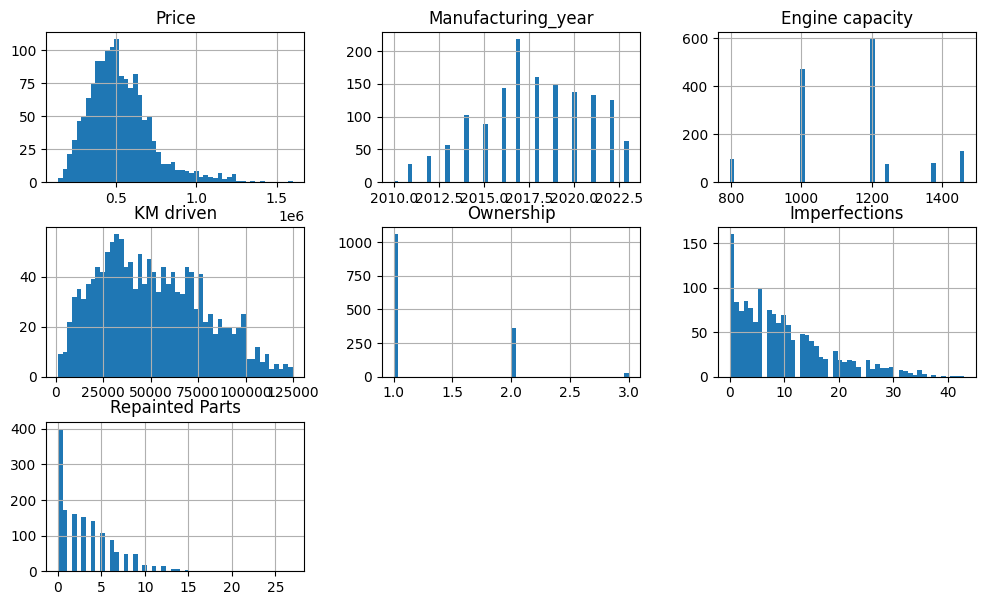

In [499]:
import matplotlib.pyplot as plt

cars_df.hist(bins=50, figsize=(12, 7))
plt.show()

We can see that the `'Price'`, `'Imperfections'` and `'Repainted Parts'` columns kind of have the heavy tail, so it would be helpful in the future to transform them to their log.

# Splitting the data

## Splitting with `sklearn`

It can simply be done with `sklearn`'s `train_test_split` function:

In [500]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cars_df, test_size=0.2, random_state=42)

## Making stratas

Or we can make stratas, based on the `'KM driven'` column and then perform the stratified split:

In [501]:
cars_df["distance_cat"] = pd.cut(cars_df["KM driven"],
                                bins=[0., 30000, 60000, 90000, 120000, np.inf],
                                labels=[1, 2, 3, 4, 5])

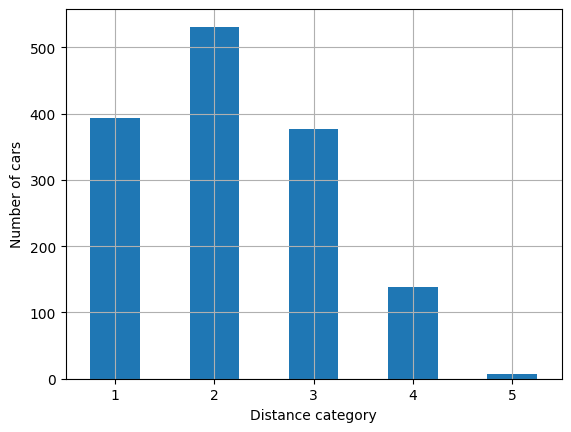

In [502]:
# displaying the categories
cars_df["distance_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Distance category")
plt.ylabel("Number of cars")
plt.show()

Using the `StratifiedShuffleSplit`:

In [503]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(cars_df, cars_df["distance_cat"]):
    strat_train_set_n = cars_df.iloc[train_index]
    strat_test_set_n = cars_df.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])    

In [504]:
# usind the first split
strat_train_set, strat_test_set = strat_splits[0]

In [505]:
# using train_test_split() with stratify argument
strat_train_set, strat_test_set = train_test_split(cars_df, test_size=0.2,
                                                  stratify=cars_df["distance_cat"],
                                                  random_state=42)

In [506]:
# checking the proportions
strat_test_set["distance_cat"].value_counts() / len(strat_test_set)

distance_cat
2    0.366782
1    0.273356
3    0.259516
4    0.096886
5    0.003460
Name: count, dtype: float64

In [507]:
# deleting the distance_cat column since it's not needed anymore
for set_ in (strat_train_set, strat_test_set):
    set_.drop("distance_cat", axis=1, inplace=True)

# Exploring the data

In [508]:
# copying the original
cars_df = strat_train_set.copy()

## Look for correlations

Computing the _standard correlation coefficient_ between every pair of attributes using the `corr()` method:

In [509]:
corr_matrix = cars_df.corr(numeric_only=True)

In [510]:
# price attribute will be our target
corr_matrix["Price"].sort_values(ascending=False)

Price                 1.000000
Engine capacity       0.712158
Manufacturing_year    0.611429
Ownership            -0.193322
Repainted Parts      -0.196336
Imperfections        -0.234800
KM driven            -0.304658
Name: Price, dtype: float64

We can also use the `scatter_matrix()` function. We'll be focusing on the most promising attributes:

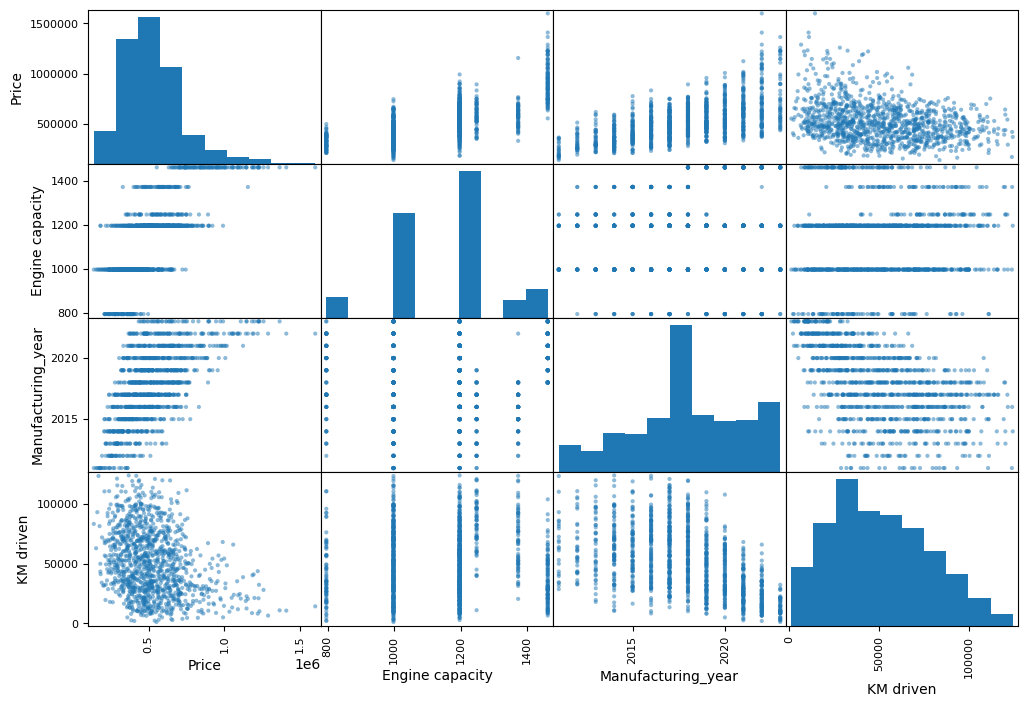

In [511]:
from pandas.plotting import scatter_matrix

attributes = ["Price", "Engine capacity", "Manufacturing_year", "KM driven"]
scatter_matrix(cars_df[attributes], figsize=(12, 8))
plt.show()

It seems like the most promising attributes to predict the price are engine capacity and km driven. We can plot their scatterplots: 

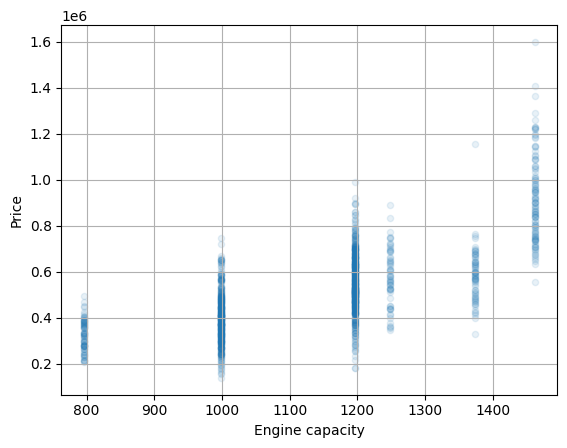

In [512]:
cars_df.plot(kind="scatter", x="Engine capacity", y="Price",
            alpha=0.1, grid=True)
plt.show()

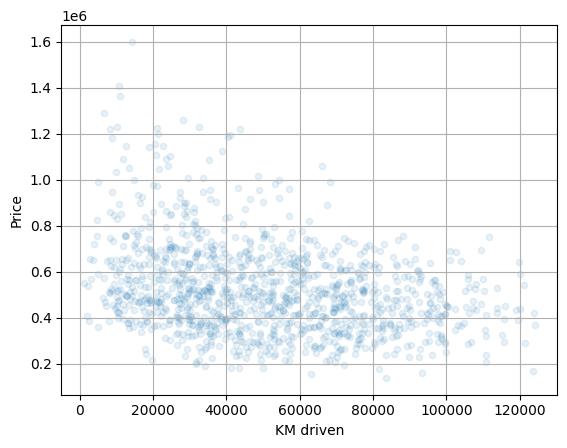

In [513]:
cars_df.plot(kind="scatter", x="KM driven", y="Price",
            alpha=0.1, grid=True)
plt.show()

# Preparing the data

## Cleaning the data

There're no missing data, so we won't be needing filling the gaps or deleting any rows. We can, howewer, delete the outliers:

In [514]:
cars_cleaned = strat_train_set.copy()

# selecting numerical values
cars_num = cars_df.select_dtypes(include=[np.number])

# declaring quantiles and getting rid of the outliers
for column in cars_num:
    lower_bound = cars_cleaned[column].quantile(0.05)
    upper_bound = cars_cleaned[column].quantile(0.95)

    cars_without_bounds = cars_cleaned[((cars_cleaned[column] >= lower_bound) &
                                       (cars_cleaned[column] <= upper_bound)) |
                                       (cars_cleaned[column].isna())]

cars_cleaned = cars_without_bounds

In [515]:
# reverting to a clean training set
# separating the predictors and the labels
cars_df = cars_cleaned.drop("Price", axis=1)
cars_labels = cars_cleaned["Price"].copy()

## Handling categorical attributes

We already know all the unique categorical values. We can use `OneHotEncoder` do encode these. We could've used `OrdinalEncoder` but then we'd need to declare our own order (what's better than other).

In [516]:
# selecting categorical values
cars_cat = cars_df.select_dtypes(include=[object])

In [517]:
# using the OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
cars_cat_1hot = cat_encoder.fit_transform(cars_cat)

In [518]:
# displaying the results
cars_cat_1hot.toarray()

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 0., 1.],
       ...,
       [0., 1., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 0., 1.]])

## Feature scaling

We can use `sklearn`'s transformer `StandardScaler` to standardize our data:

In [519]:
# using the StandardScaler
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
cars_num_std_scaled = std_scaler.fit_transform(cars_num)

In [520]:
# displaying results
cars_num_std_scaled[:5]

array([[-1.43164821, -1.2748871 , -2.04669558,  0.2348756 , -0.59076105,
        -1.15267644, -0.96271907],
       [ 0.08393425,  1.75340636, -0.85221606, -1.76428824, -0.59076105,
        -0.79415788, -0.07429179],
       [-0.29496136,  1.08045226, -0.85221606, -0.86796304, -0.59076105,
        -0.07712077, -0.66657664],
       [ 0.2426608 , -1.2748871 ,  1.36525829,  1.52713365,  1.42971166,
         0.63991634, -0.07429179],
       [ 0.02249172, -0.26545594,  0.32452366,  2.29505312,  1.42971166,
        -0.31613314,  0.51799307]])

# Making pipeline

We can make our own pipeline that will make all the necessary transformations in the given order: 

In [521]:
# changing 0 to a very small value in columns with a supposed hevay tail
# in case we want to perform the log function on it
# cars_df["Imperfections"] = cars_df["Imperfections"].replace(0, 1e-10)
# cars_df["Repainted Parts"] = cars_df["Repainted Parts"].replace(0, 1e-10)

In [522]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn import set_config

set_config(display='diagram')

# pipeline for categorical values
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# logarithmic pipeline in case we need it
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

# our default pipeline
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# preprocessing transformer
preprocessing = ColumnTransformer(
    [
        # ("log", log_pipeline, ["Imperfections", "Repainted Parts"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline
)

Now we can call the `fit_transform()` method on our data:

In [523]:
cars_prepared = preprocessing.fit_transform(cars_df)

# Selecting and training a model

## Training and evaluating on the training set

Pipelines can be used to train a model as well. We'll start with a simple linear regression model:

In [524]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(cars_df, cars_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d694c9c9a20>)])),
                ('linearregression', LinearRegression())])

Now we can compare the predicted results with the actual data:

In [525]:
cars_predictions = lin_reg.predict(cars_df)
cars_predictions[:5].round(-2)

array([136400., 588700., 559400., 531900., 522800.])

In [526]:
cars_labels.iloc[:5].values

array([244000, 540000, 466000, 571000, 528000])

In [527]:
# computing the error ratios
error_ratios = cars_predictions[:5].round(-2) / cars_labels[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-44.1%, 9.0%, 20.0%, -6.8%, -1.0%


In [528]:
# using RMSE
try:
  from sklearn.metrics import root_mean_squared_error
except ImportError:
  from sklearn.metrics import mean_squared_error

  def root_mean_squared_error(labels, predictions):
    return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(cars_labels, cars_predictions)
lin_rmse # the smaller - the better

83141.38435115921

Not a very great score. We can try another regressor - `DesicionTreeRegressor`:

In [529]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(cars_df, cars_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d694c9c9a20>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

Now we better be evaluating using the cross-validation. The following code randomly splits the training set into $10$ nonoverlapping subsets called folds, then it trains and evaluates the decision tree model $10$ times, picking a different fold for evaluation every time and using the other $9$ folds for training:

In [530]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, cars_df, cars_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [531]:
# now to see the results
pd.Series(tree_rmses).describe()

count        10.000000
mean     103349.522849
std        7889.866974
min       93839.713831
25%       96395.989703
50%      104571.559556
75%      107386.746221
max      117625.685128
dtype: float64

Now it's even worse than the Linear Model:

In [532]:
# errors for the Linear model
lin_rmses = -cross_val_score(lin_reg, cars_df, cars_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count        10.000000
mean      83341.970701
std       11285.555711
min       71362.998947
25%       74218.983879
50%       80534.177739
75%       92356.287971
max      103653.208086
dtype: float64

We can try yes another model - `RandomForestRegressor`, which trains multiple trees (*ensembles*):

In [533]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, cars_df, cars_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [534]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     76556.500539
std       8764.895360
min      60578.401311
25%      72396.041589
50%      74561.427330
75%      83502.706245
max      90836.596224
dtype: float64

That's much better. Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [535]:
forest_reg.fit(cars_df, cars_labels)
cars_predictions = forest_reg.predict(cars_df)
forest_rmse = root_mean_squared_error(cars_labels, cars_predictions)
forest_rmse

29116.086104196813

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

# Fine-Tuning the model

## Randomized Search

Try 30 (`n_iter` × `cv`) random combinations of hyperparameters:

In [536]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

params_distribs = {
    'random_forest__max_features': randint(low=2, high=20)
}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=params_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42
)

rnd_search.fit(cars_df, cars_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehotencoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7d694c9c9a20>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d694d33d1b0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [537]:
# display the results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by='mean_test_score', ascending=False, inplace=True)
cv_res = cv_res[[
    "param_random_forest__max_features",
    "split0_test_score",
    "split1_test_score",
    "split2_test_score",
    "mean_test_score"
]]
score_cols = ["split0", "split1", "spli2", "mean_test_rmse"]
cv_res.columns = ["max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,max_features,split0,split1,spli2,mean_test_rmse
7,5,67984,75501,79970,74485
0,8,70006,76494,78592,75030
4,8,70006,76494,78592,75030
3,9,69426,76745,79128,75100
8,9,69426,76745,79128,75100


# Analyze the Best Model and Their Errors

In [538]:
final_model = rnd_search.best_estimator_ # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.23, 0.51, 0.09, 0.01,
       0.06, 0.03])

Let’s sort these importance scores in descending order and display them next to their corresponding attribute names:

In [539]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(0.5122272687537233, 'remainder__Engine capacity'),
 (0.2339820593004661, 'remainder__Manufacturing_year'),
 (0.0911881487408151, 'remainder__KM driven'),
 (0.05842695083790213, 'remainder__Imperfections'),
 (0.034306849102675986, 'remainder__Repainted Parts'),
 (0.014588608261772855, 'cat__Transmission_Automatic'),
 (0.012080731791689088, 'cat__Transmission_Manual'),
 (0.010732734188092856, 'remainder__Ownership'),
 (0.007107721551999711, 'cat__Spare key_Yes'),
 (0.0070874717487249324, 'cat__Fuel type_Petrol'),
 (0.0070738834038173385, 'cat__Fuel type_Diesel'),
 (0.0061519324069713765, 'cat__Spare key_No'),
 (0.0050456399113493824, 'cat__Fuel type_CNG')]

# Evaluate the system on the Test Set

In [540]:
X_test = strat_test_set.drop("Price", axis=1)
y_test = strat_test_set["Price"].copy()

# X_test["Imperfections"] = cars_df["Imperfections"].replace(0, 1e-10)
# X_test["Repainted Parts"] = cars_df["Repainted Parts"].replace(0, 1e-10)

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

71102.58712972258


We can compute a $95\%$ confidence interval for the test RMSE:

In [541]:
from scipy import stats

def rmse(squared_error):
  return np.sqrt(np.mean(squared_error))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [542]:
rmse_lower, rmse_upper

(65028.40704178794, 79454.01339357281)

Now we can check the $R^2$ score for our best model:

In [543]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, final_predictions)
r2

0.8734380417016747

We have $87.3\%$ accuracy.

**Thank you! Please upvote :)**